In [66]:
import pandas as pd

weather = pd.read_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\weather_yearly.csv"
)

print(weather.head())

print(
    weather.groupby(
        ["kabupaten","tahun"]
    ).size().head(20)
)

   Unnamed: 0   kabupaten  tahun  temperature   temp_max   temp_min  rainfall  \
0           0  ACEH BARAT   2015    26.452110  27.958082  25.246904   2443.15   
1           1  ACEH BARAT   2016    26.562650  28.130601  25.324016   3299.55   
2           2  ACEH BARAT   2017    26.343233  27.936356  25.094658   2628.98   
3           3  ACEH BARAT   2018    26.383507  27.876822  25.236767   2826.55   
4           4  ACEH BARAT   2019    26.726247  28.311479  25.519671   2237.04   

    humidity  wind_speed  solar_radiation  
0  83.821644    1.453260        17.427973  
1  84.334399    1.474973        17.387186  
2  83.402000    1.462219        17.314767  
3  83.776986    1.437233        17.310822  
4  83.668603    1.419205        17.766027  
kabupaten        tahun
ACEH BARAT       2015     1
                 2016     1
                 2017     1
                 2018     1
                 2019     1
                 2020     1
                 2021     1
                 2022     1
  

In [67]:
#cek kabupaten kota 
crop = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\crop_productivity.csv"
)

print(
    crop["kabupaten"]
    .nunique()
)

print(
    sorted(
        crop["kabupaten"].unique()
    )
)

21
['BANDUNG', 'BANDUNG BARAT', 'BANJAR', 'BEKASI', 'BOGOR', 'CIAMIS', 'CIANJUR', 'CIMAHI', 'CIREBON', 'DEPOK', 'GARUT', 'INDRAMAYU', 'KARAWANG', 'KUNINGAN', 'MAJALENGKA', 'PANGANDARAN', 'PURWAKARTA', 'SUBANG', 'SUKABUMI', 'SUMEDANG', 'TASIKMALAYA']


In [68]:
weather = pd.read_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\weather_yearly.csv"
)

crop = pd.read_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\crop_productivity.csv"
)

kabupaten_jabar = (
    crop["kabupaten"]
    .unique()
)

weather_jabar = weather[
    weather["kabupaten"]
    .isin(kabupaten_jabar)
]

print(weather_jabar.shape)

(231, 10)


In [69]:
weather_jabar.to_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\intermediate\weather_jabar.csv",
    index=False
)

In [70]:
final_df = crop.merge(
    weather_jabar,
    on=[
        "kabupaten",
        "tahun"
    ],
    how="inner"
)

print(final_df.shape)

(594, 12)


In [71]:
print(
    final_df["komoditas"]
    .value_counts()
)

komoditas
Jagung      216
Ubi Kayu    216
Padi        162
Name: count, dtype: int64


In [72]:
crop = pd.read_csv(
   r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\crop_productivity.csv"
)

print(
    crop.groupby("komoditas")["tahun"]
    .agg(["min","max","nunique"])
)

            min   max  nunique
komoditas                     
Jagung     2015  2022        8
Padi       2015  2020        6
Ubi Kayu   2015  2022        8


In [73]:
final_df = final_df[
    final_df["tahun"].between(
        2015,
        2020
    )
]

print(
    final_df["komoditas"]
    .value_counts()
)

komoditas
Padi        162
Jagung      162
Ubi Kayu    162
Name: count, dtype: int64


In [74]:
print(final_df.shape)

(486, 12)


In [75]:
print(final_df.info())

<class 'pandas.DataFrame'>
Index: 486 entries, 0 to 539
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kabupaten        486 non-null    str    
 1   tahun            486 non-null    int64  
 2   produktivitas    486 non-null    float64
 3   komoditas        486 non-null    str    
 4   Unnamed: 0       486 non-null    int64  
 5   temperature      486 non-null    float64
 6   temp_max         486 non-null    float64
 7   temp_min         486 non-null    float64
 8   rainfall         486 non-null    float64
 9   humidity         486 non-null    float64
 10  wind_speed       486 non-null    float64
 11  solar_radiation  486 non-null    float64
dtypes: float64(8), int64(2), str(2)
memory usage: 55.9 KB
None


In [76]:
#hapus unnamed
final_df = final_df.drop(columns=["Unnamed: 0"])

In [77]:
print(final_df.describe())

             tahun  produktivitas  temperature    temp_max    temp_min  \
count   486.000000     486.000000   486.000000  486.000000  486.000000   
mean   2017.500000     106.312160    24.491050   28.222931   21.626834   
std       1.709585      94.115033     1.619465    1.351264    1.886631   
min    2015.000000       0.000000    21.359781   25.473479   17.835370   
25%    2016.000000      55.027500    23.652493   27.454630   20.496230   
50%    2017.500000      64.525000    24.854685   28.628438   21.802041   
75%    2019.000000     153.932500    25.741178   29.196575   23.139890   
max    2020.000000     485.240000    26.912356   30.597164   25.074986   

           rainfall    humidity  wind_speed  solar_radiation  
count    486.000000  486.000000  486.000000       486.000000  
mean    4434.284198   85.937020    1.676388        17.932037  
std     2099.002584    3.167900    0.487638         0.806083  
min     1814.700000   77.436712    0.090410        16.410000  
25%     2797.96000

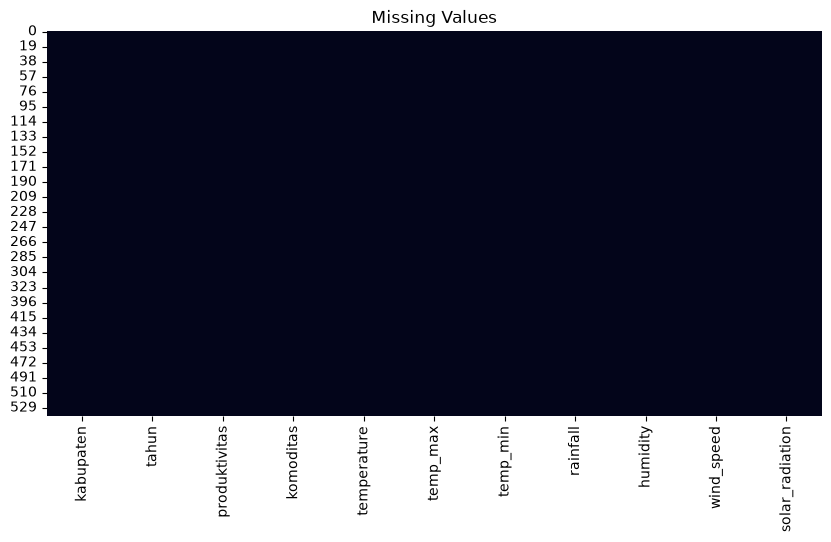

In [78]:
#missing value check
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    final_df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

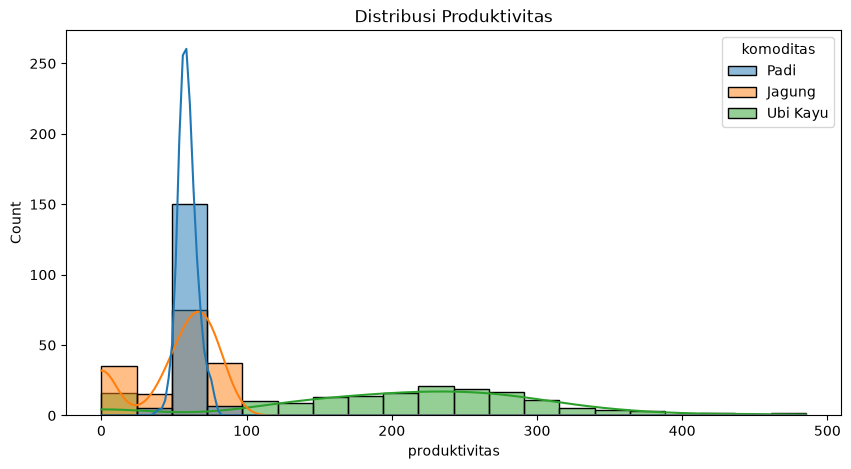

In [79]:
#distribusi produktivitas
plt.figure(figsize=(10,5))

sns.histplot(
    data=final_df,
    x="produktivitas",
    hue="komoditas",
    kde=True
)

plt.title(
    "Distribusi Produktivitas"
)

plt.show()

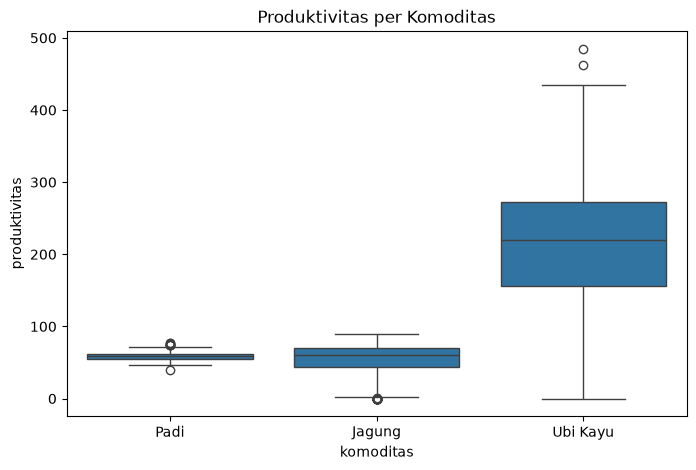

In [80]:
#boxplot produktivitas
plt.figure(figsize=(8,5))

sns.boxplot(
    data=final_df,
    x="komoditas",
    y="produktivitas"
)

plt.title(
    "Produktivitas per Komoditas"
)

plt.show()

In [81]:
#rata-rata produktivitas
avg_prod = (
    final_df
    .groupby("komoditas")
    ["produktivitas"]
    .mean()
    .reset_index()
)

print(avg_prod)

  komoditas  produktivitas
0    Jagung      50.756173
1      Padi      59.232284
2  Ubi Kayu     208.948025


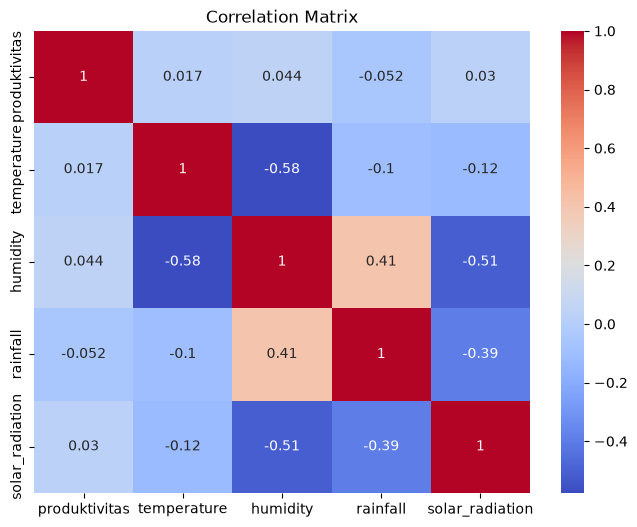

In [82]:
#cuaca vs produktivitas 
corr = final_df[
    [
        "produktivitas",
        "temperature",
        "humidity",
        "rainfall",
        "solar_radiation"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()

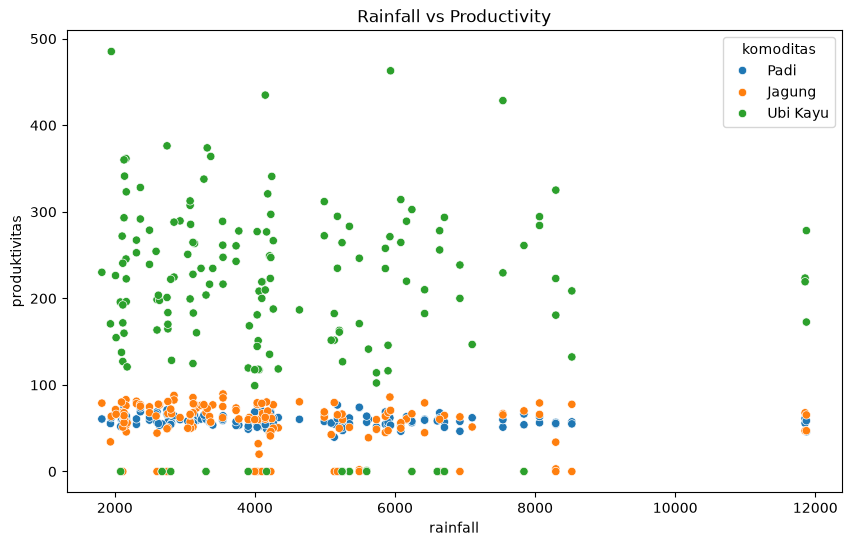

In [83]:
#curah hujan vs produktivitas 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=final_df,
    x="rainfall",
    y="produktivitas",
    hue="komoditas"
)

plt.title(
    "Rainfall vs Productivity"
)

plt.show()

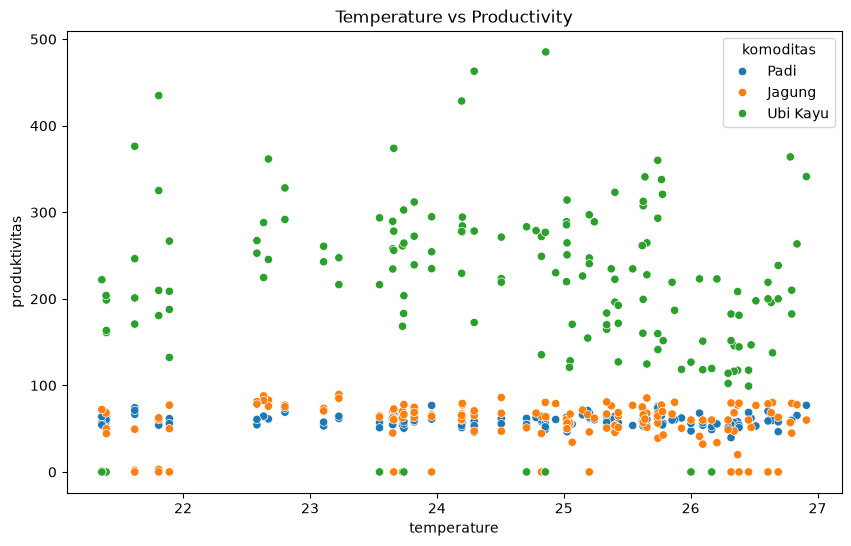

In [84]:
#temperatur vs produktivitas 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=final_df,
    x="temperature",
    y="produktivitas",
    hue="komoditas"
)

plt.title(
    "Temperature vs Productivity"
)

plt.show()

In [85]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 486 entries, 0 to 539
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kabupaten        486 non-null    str    
 1   tahun            486 non-null    int64  
 2   produktivitas    486 non-null    float64
 3   komoditas        486 non-null    str    
 4   temperature      486 non-null    float64
 5   temp_max         486 non-null    float64
 6   temp_min         486 non-null    float64
 7   rainfall         486 non-null    float64
 8   humidity         486 non-null    float64
 9   wind_speed       486 non-null    float64
 10  solar_radiation  486 non-null    float64
dtypes: float64(8), int64(1), str(2)
memory usage: 52.2 KB


In [86]:
final_df.duplicated().sum()

np.int64(2)

In [87]:
print(
    final_df[
        final_df.duplicated(keep=False)
    ]
)

    kabupaten  tahun  produktivitas komoditas  temperature   temp_max  \
219   BANDUNG   2017            0.0    Jagung    21.393123  25.473479   
236   BANDUNG   2017            0.0    Jagung    21.393123  25.473479   
435   BANDUNG   2017            0.0  Ubi Kayu    21.393123  25.473479   
452   BANDUNG   2017            0.0  Ubi Kayu    21.393123  25.473479   

      temp_min  rainfall   humidity  wind_speed  solar_radiation  
219  18.304849   6603.78  89.079507    1.545918        17.635548  
236  18.304849   6603.78  89.079507    1.545918        17.635548  
435  18.304849   6603.78  89.079507    1.545918        17.635548  
452  18.304849   6603.78  89.079507    1.545918        17.635548  


In [88]:
final_df = final_df.drop_duplicates()

print(final_df.shape)

(484, 11)


In [89]:
final_df.duplicated().sum()

np.int64(0)

In [90]:
final_df[
    ["kabupaten","tahun","komoditas"]
].duplicated().sum()

np.int64(106)

In [91]:
final_df.groupby("komoditas")[
    "produktivitas"
].apply(
    lambda x: (x == 0).sum()
)


komoditas
Jagung      30
Padi         0
Ubi Kayu    14
Name: produktivitas, dtype: int64

In [92]:
dup_keys = (
    final_df
    .groupby(
        ["kabupaten","tahun","komoditas"]
    )
    .size()
    .reset_index(name="count")
)

dup_keys[
    dup_keys["count"] > 1
].sort_values(
    "count",
    ascending=False
)

,kabupaten,tahun,komoditas,count
0,BANDUNG,2015,Jagung,2
1,BANDUNG,2015,Padi,2
2,BANDUNG,2015,Ubi Kayu,2
3,BANDUNG,2016,Jagung,2
4,BANDUNG,2016,Padi,2
...,...,...,...,...
373,TASIKMALAYA,2019,Padi,2
374,TASIKMALAYA,2019,Ubi Kayu,2
375,TASIKMALAYA,2020,Jagung,2
376,TASIKMALAYA,2020,Padi,2


In [93]:
crop = pd.read_csv(r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\crop_productivity.csv")

crop.groupby(
    ["kabupaten","tahun","komoditas"]
).size().value_counts()

1    330
2    132
Name: count, dtype: int64

In [94]:
dup_crop = crop[
    crop.duplicated(
        subset=["kabupaten","tahun","komoditas"],
        keep=False
    )
].sort_values(
    ["kabupaten","tahun","komoditas"]
)

print(dup_crop)

       kabupaten  tahun  produktivitas komoditas
165      BANDUNG   2015          49.86    Jagung
182      BANDUNG   2015           0.00    Jagung
3        BANDUNG   2015          59.50      Padi
20       BANDUNG   2015          63.71      Padi
381      BANDUNG   2015         163.03  Ubi Kayu
..           ...    ...            ...       ...
565  TASIKMALAYA   2021         309.03  Ubi Kayu
356  TASIKMALAYA   2022          68.17    Jagung
376  TASIKMALAYA   2022          75.70    Jagung
572  TASIKMALAYA   2022         269.18  Ubi Kayu
592  TASIKMALAYA   2022         320.04  Ubi Kayu

[264 rows x 4 columns]


In [95]:
for komoditas in crop["komoditas"].unique():

    temp = crop[
        crop["komoditas"] == komoditas
    ]

    print(
        komoditas,
        temp[
            ["kabupaten","tahun"]
        ].duplicated().sum()
    )

Padi 36
Jagung 48
Ubi Kayu 48


In [96]:
crop_clean = crop.drop_duplicates(
    subset=[
        "kabupaten",
        "tahun",
        "komoditas"
    ]
)

print(crop_clean.shape)

(462, 4)


In [97]:
crop_clean.groupby(
    ["kabupaten","tahun","komoditas"]
).size().value_counts()

1    462
Name: count, dtype: int64

In [98]:
print(crop_clean.shape)

print(
    crop_clean["komoditas"]
    .value_counts()
)

(462, 4)
komoditas
Jagung      168
Ubi Kayu    168
Padi        126
Name: count, dtype: int64


In [99]:
crop_clean.groupby(
    "komoditas"
)["tahun"].agg(
    ["min","max","nunique"]
)

,min,max,nunique
komoditas,,,
Jagung,2015,2022,8
Padi,2015,2020,6
Ubi Kayu,2015,2022,8


In [100]:
#crop balanced
common_years = [2015,2016,2017,2018,2019,2020]

crop_balanced = crop_clean[
    crop_clean["tahun"].isin(common_years)
]

print(crop_balanced)

         kabupaten  tahun  produktivitas komoditas
0            BOGOR   2015          63.26      Padi
1         SUKABUMI   2015          57.84      Padi
2          CIANJUR   2015          59.41      Padi
3          BANDUNG   2015          59.50      Padi
4            GARUT   2015          60.79      Padi
..             ...    ...            ...       ...
529  BANDUNG BARAT   2020         434.86  Ubi Kayu
530    PANGANDARAN   2020         340.93  Ubi Kayu
536          DEPOK   2020         250.88  Ubi Kayu
537         CIMAHI   2020         209.74  Ubi Kayu
539         BANJAR   2020         223.00  Ubi Kayu

[378 rows x 4 columns]


In [101]:
print(crop_balanced.shape)

print(
    crop_balanced["komoditas"]
    .value_counts()
)

print(
    crop_balanced.groupby("komoditas")["tahun"]
    .agg(["min","max","nunique"])
)

(378, 4)
komoditas
Padi        126
Jagung      126
Ubi Kayu    126
Name: count, dtype: int64
            min   max  nunique
komoditas                     
Jagung     2015  2020        6
Padi       2015  2020        6
Ubi Kayu   2015  2020        6


In [102]:
common_years = [2015,2016,2017,2018,2019,2020]

weather_balanced = weather[
    weather["tahun"].isin(common_years)
]
print(crop_balanced["kabupaten"].nunique())
print(weather_balanced["kabupaten"].nunique())

21
488


In [103]:
set(crop_balanced["kabupaten"]) - set(weather_balanced["kabupaten"])

set()

In [104]:
final_df = crop_balanced.merge(
    weather_balanced,
    on=["kabupaten","tahun"],
    how="inner"
)

In [105]:
print(final_df.shape)

print(
    final_df[
        ["kabupaten","tahun","komoditas"]
    ].duplicated().sum()
)

print(
    final_df.isnull().sum()
)

(378, 12)
0
kabupaten          0
tahun              0
produktivitas      0
komoditas          0
Unnamed: 0         0
temperature        0
temp_max           0
temp_min           0
rainfall           0
humidity           0
wind_speed         0
solar_radiation    0
dtype: int64


In [106]:
final_df = final_df.loc[
    :,
    ~final_df.columns.str.contains("^Unnamed")
]
print(final_df.columns.tolist())

['kabupaten', 'tahun', 'produktivitas', 'komoditas', 'temperature', 'temp_max', 'temp_min', 'rainfall', 'humidity', 'wind_speed', 'solar_radiation']


In [107]:
#final dataset
final_df.to_csv(
    r"C:\Users\hilmi\Documents\Dibimbing\Final Project\Project\menanam-ai\data\primary\final_dataset_clean.csv",
    index=False
)

In [108]:
print(final_df.shape)

print(final_df.isnull().sum().sum())

print(final_df.duplicated().sum())

print(
    final_df[
        ["kabupaten","tahun","komoditas"]
    ].duplicated().sum()
)

(378, 11)
0
0
0


<Axes: xlabel='komoditas', ylabel='count'>

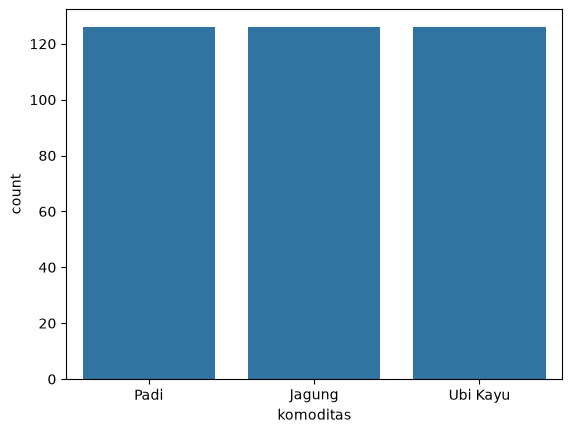

In [109]:
#eda final
#distribusi komoditas
sns.countplot(
    data=final_df,
    x="komoditas"
)

<Axes: xlabel='produktivitas', ylabel='Count'>

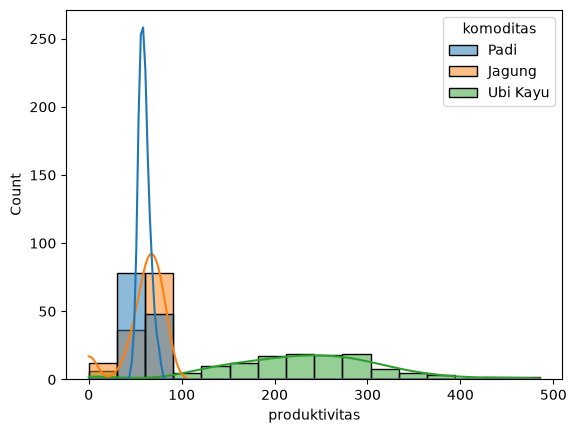

In [110]:
#eda final 
#distribusi produktivitas
sns.histplot(
    data=final_df,
    x="produktivitas",
    hue="komoditas",
    kde=True
)

<Axes: xlabel='komoditas', ylabel='produktivitas'>

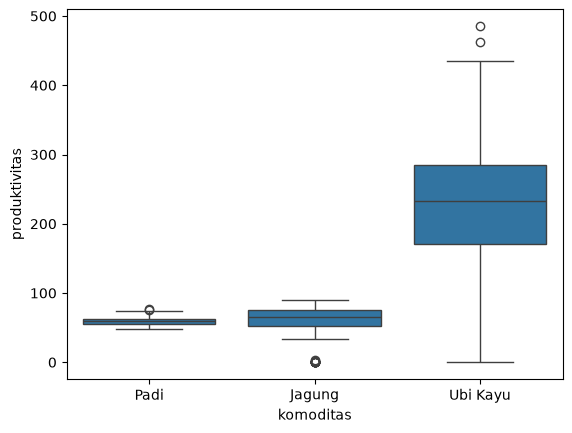

In [111]:
#eda final 
#boxplot produktivitas
sns.boxplot(
    data=final_df,
    x="komoditas",
    y="produktivitas"
)

<Axes: >

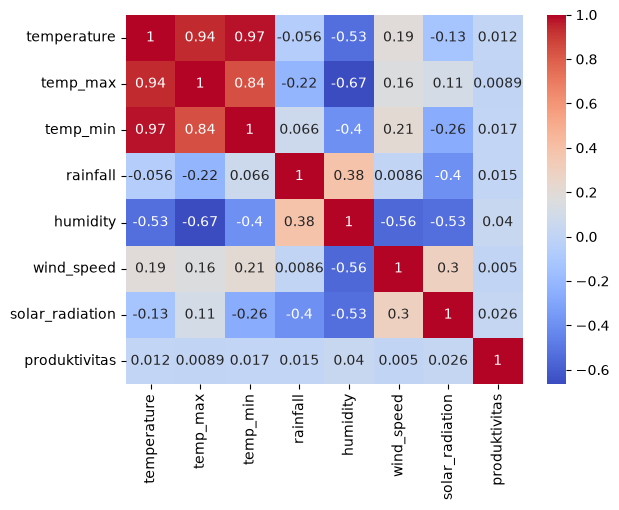

In [112]:
#eda final
#heatmap correlation 
corr = final_df[
    [
        "temperature",
        "temp_max",
        "temp_min",
        "rainfall",
        "humidity",
        "wind_speed",
        "solar_radiation",
        "produktivitas"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

<Axes: xlabel='rainfall', ylabel='produktivitas'>

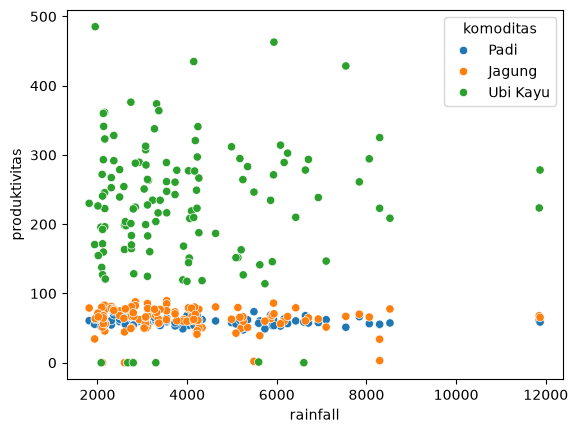

In [113]:
#eda final
#rainfall vs productivity
sns.scatterplot(
    data=final_df,
    x="rainfall",
    y="produktivitas",
    hue="komoditas"
)

<Axes: xlabel='temperature', ylabel='produktivitas'>

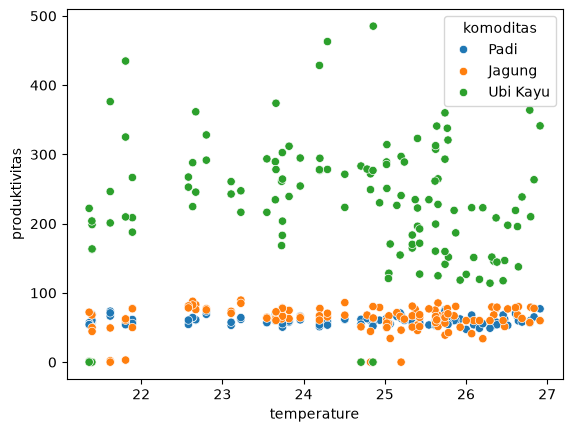

In [114]:
#eda final 
#temperature vs productivity 
sns.scatterplot(
    data=final_df,
    x="temperature",
    y="produktivitas",
    hue="komoditas"
)

<Axes: xlabel='kabupaten'>

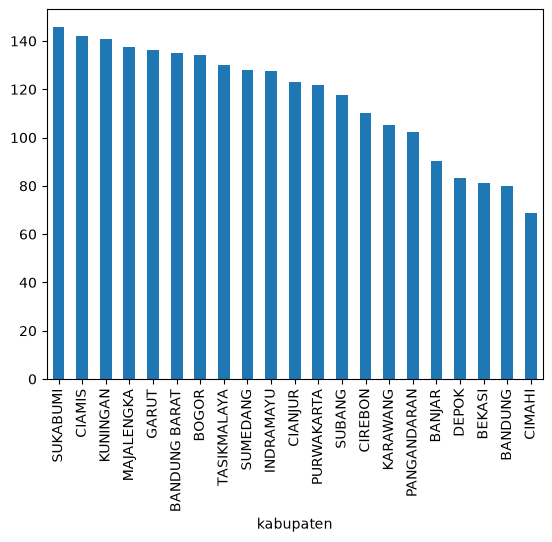

In [115]:
#eda final
#productivity per city
top = (
    final_df
    .groupby("kabupaten")
    ["produktivitas"]
    .mean()
    .sort_values(ascending=False)
)

top.plot(kind="bar")

In [117]:
df_encoded = pd.get_dummies(
    final_df,
    columns=["komoditas"],
    dtype=int
)

df_encoded.head()

,kabupaten,tahun,produktivitas,temperature,temp_max,temp_min,rainfall,humidity,wind_speed,solar_radiation,komoditas_Jagung,komoditas_Padi,komoditas_Ubi Kayu
0,BOGOR,2015,63.26,24.824247,29.196575,21.260603,4209.40,83.252356,1.402192,17.839014,0,1,0
1,SUKABUMI,2015,57.84,23.821534,28.246411,20.385260,4990.16,85.411260,1.528082,18.659658,0,1,0
2,CIANJUR,2015,59.41,23.821534,28.246411,20.385260,2495.08,85.411260,1.528082,18.590795,0,1,0
3,BANDUNG,2015,59.50,21.395534,26.023562,17.835370,5204.82,86.703808,1.416192,18.873466,0,1,0
4,GARUT,2015,60.79,22.672356,27.160493,19.296219,2159.37,86.170055,1.572795,19.156137,0,1,0


In [118]:
df_encoded.value_counts()

kabupaten      tahun  produktivitas  temperature  temp_max   temp_min   rainfall  humidity   wind_speed  solar_radiation  komoditas_Jagung  komoditas_Padi  komoditas_Ubi Kayu
BOGOR          2015   63.26          24.824247    29.196575  21.260603  4209.40   83.252356  1.402192    17.839014        0                 1               0                     1
SUKABUMI       2015   57.84          23.821534    28.246411  20.385260  4990.16   85.411260  1.528082    18.659658        0                 1               0                     1
CIANJUR        2015   59.41          23.821534    28.246411  20.385260  2495.08   85.411260  1.528082    18.590795        0                 1               0                     1
BANDUNG        2015   59.50          21.395534    26.023562  17.835370  5204.82   86.703808  1.416192    18.873466        0                 1               0                     1
GARUT          2015   60.79          22.672356    27.160493  19.296219  2159.37   86.170055  1.572795    

In [120]:
print(df_encoded.columns.tolist())

['kabupaten', 'tahun', 'produktivitas', 'temperature', 'temp_max', 'temp_min', 'rainfall', 'humidity', 'wind_speed', 'solar_radiation', 'komoditas_Jagung', 'komoditas_Padi', 'komoditas_Ubi Kayu']


<Axes: >

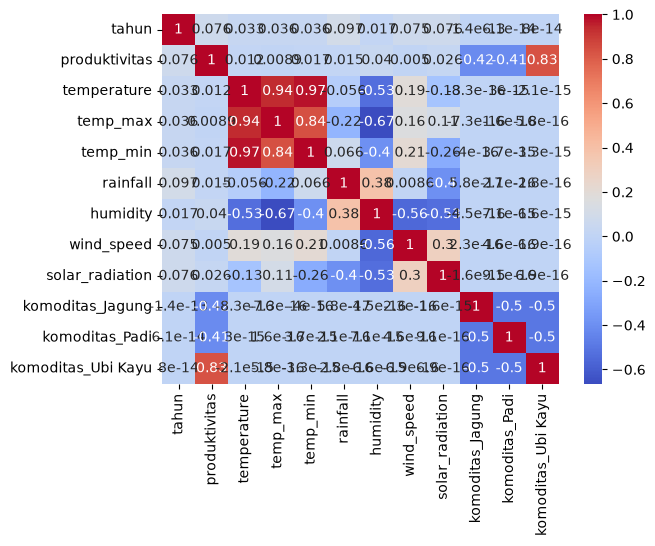

In [122]:
#heatmap komoditas vs produktivitas 
corr = df_encoded.select_dtypes(
    include="number"
).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [123]:
#cek jumlah produktivitas 
final_df[
    final_df["produktivitas"] == 0
]

,kabupaten,tahun,produktivitas,komoditas,temperature,temp_max,temp_min,rainfall,humidity,wind_speed,solar_radiation
144,DEPOK,2015,0.0,Jagung,24.824247,29.196575,21.260603,2104.70,83.252356,1.402192,17.839014
145,CIMAHI,2015,0.0,Jagung,21.395534,26.023562,17.835370,2602.41,86.703808,1.416192,18.590795
171,BANDUNG,2017,0.0,Jagung,21.393123,25.473479,18.304849,6603.78,89.079507,1.545918,17.635548
186,DEPOK,2017,0.0,Jagung,24.707096,28.515014,21.702685,2674.52,86.250877,1.448411,17.014274
187,CIMAHI,2017,0.0,Jagung,21.393123,25.473479,18.304849,3301.89,89.079507,1.545918,17.612521
207,DEPOK,2018,0.0,Jagung,24.854685,29.057205,21.477178,2083.34,83.704438,1.413425,17.629726
208,CIMAHI,2018,0.0,Jagung,21.359781,25.767205,18.004164,2797.96,87.626548,1.502110,18.398247
228,DEPOK,2019,0.0,Jagung,25.201178,29.711808,21.484192,2113.59,81.901918,1.293178,18.370082
229,CIMAHI,2019,0.0,Jagung,21.619205,26.396301,17.983616,2745.19,86.059616,1.434767,19.177096
297,BANDUNG,2017,0.0,Ubi Kayu,21.393123,25.473479,18.304849,6603.78,89.079507,1.545918,17.635548


In [124]:
final_df = final_df[
    final_df["produktivitas"] > 0
]

In [126]:
final_df.shape

(364, 11)

In [127]:
final_df.groupby("komoditas")[
    "produktivitas"
].describe()

,count,mean,std,min,25%,50%,75%,max
komoditas,,,,,,,,
Jagung,117.0,64.118376,15.656740,1.00,57.230,66.02,76.4200,89.58
Padi,126.0,59.820952,5.852174,47.35,55.695,59.10,63.1425,77.01
Ubi Kayu,121.0,238.939256,78.508964,1.00,186.730,234.71,288.0900,485.24


#Padi
Mean = 59.82
Std  = 5.85
Produktivitas relatif stabil.
Variasi antar kabupaten dan tahun tidak terlalu besar.

#Jagung 
Mean = 64.12
Std  = 15.66
Lebih fluktuatif dibanding padi.
Kemungkinan lebih sensitif terhadap kondisi iklim.

#Ubi Kayu/Singkong 
Mean = 238.94
Std  = 78.51
Produktivitas jauh lebih tinggi.
Variasinya juga paling besar.

In [128]:
#ubi kayu = singkong
final_df["komoditas"] = final_df["komoditas"].replace(
    {
        "Ubi Kayu": "Singkong"
    }
)

In [129]:
final_df["komoditas"].value_counts()

komoditas
Padi        126
Singkong    121
Jagung      117
Name: count, dtype: int64

In [133]:
final_df.to_csv(
    "../data/primary/final_dataset_modeling.csv",
    index=False
)

In [130]:
#balancing ulang data karena ada produktivitas 0 (akibat dari tidak ada penanaman atau karena lokasi)
from sklearn.utils import resample

# pisahkan per komoditas
padi = final_df[final_df["komoditas"] == "Padi"]
jagung = final_df[final_df["komoditas"] == "Jagung"]
singkong = final_df[final_df["komoditas"] == "Singkong"]

# target jumlah
n_samples = 117

# downsample
padi_balanced = resample(
    padi,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

singkong_balanced = resample(
    singkong,
    replace=False,
    n_samples=n_samples,
    random_state=42
)

# jagung sudah 117
jagung_balanced = jagung

# gabungkan
balanced_df = pd.concat([
    padi_balanced,
    jagung_balanced,
    singkong_balanced
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

balanced_df["komoditas"].value_counts()

komoditas
Jagung      117
Singkong    117
Padi        117
Name: count, dtype: int64

In [134]:
balanced_df.to_csv(
    "../data/models_input/final_dataset_modeling_balanced.csv",
    index=False
)